<a href="https://colab.research.google.com/github/sarthakthanekar70-hub/Assignment-no.17/blob/main/Task_no_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [36]:
from google.colab import files
upload = files.upload()
print(upload)

Saving cardata.csv to cardata (1).csv
{'cardata (1).csv': b'Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner\r\nritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0\r\nsx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0\r\nciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0\r\nwagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0\r\nswift,2014,4.6,6.87,42450,Diesel,Dealer,Manual,0\r\nvitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0\r\nciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0\r\ns cross,2015,6.5,8.61,33429,Diesel,Dealer,Manual,0\r\nciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0\r\nciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0\r\nalto 800,2017,2.85,3.6,2135,Petrol,Dealer,Manual,0\r\nciaz,2015,6.85,10.38,51000,Diesel,Dealer,Manual,0\r\nciaz,2015,7.5,9.94,15000,Petrol,Dealer,Automatic,0\r\nertiga,2015,6.1,7.71,26000,Petrol,Dealer,Manual,0\r\ndzire,2009,2.25,7.21,77427,Petrol,Dealer,Manual,0\r\nertiga,2016,7.75,10.79,43000,Diesel,Dealer,Man

In [42]:
df = pd.read_csv('/content/cardata.csv')
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


# Car Data Analysis Project

## Project Description
This project involves loading, exploring, and potentially modeling car data from a CSV file. The goal is to analyze various features of cars such as `Selling_Price`, `Present_Price`, `Kms_Driven`, `Fuel_Type`, `Seller_Type`, `Transmission`, and `Owner` to gain insights into factors influencing car prices.

## Setup and Prerequisites
To run this notebook, you will need to have the following Python libraries installed:
- `pandas`
- `matplotlib`
- `seaborn`
- `scikit-learn`

You can install them using pip:
```bash
pip install pandas matplotlib seaborn scikit-learn
```

## Data
The project uses `cardata.csv` which contains various attributes of cars. This file is expected to be uploaded to the Colab environment.

## Analysis Steps (So Far)
1.  **Load Data**: The `cardata.csv` file is loaded into a pandas DataFrame.
2.  **Initial Inspection**: The head of the DataFrame is displayed to get a glimpse of the data structure and content.

## Next Steps (Potential)
-   Perform Exploratory Data Analysis (EDA) to understand distributions and relationships.
-   Preprocess data (e.g., handle categorical variables, scale numerical features).
-   Build a machine learning model for car price prediction.
-   Evaluate the model's performance.

In [40]:
# ==========================================
#Q2. (Dataset Selection & Initial Exploration)
# ==========================================
df.head(10)

#Justification for Q2 (Write this in your assignment report):
#I chose the 'House Price' dataset because predicting real estate values is a practical,
#real-world application of machine learning. The continuous target variable I want to
#predict is 'Price'. Understanding house pricing helps buyers and sellers make informed
#financial decisions based on property features like size, location, and rooms.


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [41]:
# ==========================================
# Q3: Missing & Duplicate Values Analysis
# ==========================================

print("\n--- Q3: Missing & Duplicate Values Analysis ---")

# 1. Check for missing values and calculate their percentage
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine them into a clean summary table
missing_summary = pd.DataFrame({'Missing Values': missing_count, 'Percentage (%)': missing_percentage})
print("\nMissing Values Summary:")
print(missing_summary)

# 2. Handle missing values appropriately (Example: Fill numeric with median, drop others)
# Option A: Drop rows with missing values (uncomment if you want to use this)
# df = df.dropna()

# Option B: Fill missing values with median for numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print("\nMissing values have been handled.")

# 3. Check and remove duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows have been successfully removed.")





--- Q3: Missing & Duplicate Values Analysis ---

Missing Values Summary:
               Missing Values  Percentage (%)
Car_Name                    0             0.0
Year                        0             0.0
Selling_Price               0             0.0
Present_Price               0             0.0
Kms_Driven                  0             0.0
Fuel_Type                   0             0.0
Seller_Type                 0             0.0
Transmission                0             0.0
Owner                       0             0.0

Missing values have been handled.

Number of duplicate rows found: 2
Duplicate rows have been successfully removed.


In [15]:
# ==========================================
# Q4: Statistical Summary
# ==========================================

print("\n--- Q4: Statistical Summary ---")

# 1. Use describe() to generate statistical summary of numeric columns
print("\nStatistical Summary of Numeric Columns:")
print(df.describe())

# 2. Identify min, max, mean, and median of the target variable
# (Replace 'Price' with your actual continuous target column name)
target_variable = 'Selling_Price'

if target_variable in df.columns:
    print(f"\nMetrics for Target Variable Column ('{target_variable}'):")
    print(f"Minimum: {df[target_variable].min()}")
    print(f"Maximum: {df[target_variable].max()}")
    print(f"Mean   : {df[target_variable].mean()}")
    print(f"Median : {df[target_variable].median()}")
else:
    print(f"\nColumn '{target_variable}' not found. Please update the target_variable name.")


--- Q4: Statistical Summary ---

Statistical Summary of Numeric Columns:
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   299.000000     299.000000     299.000000     299.000000  299.000000
mean   2013.615385       4.589632       7.541037   36916.752508    0.043478
std       2.896868       4.984240       8.567887   39015.170352    0.248720
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.850000       1.200000   15000.000000    0.000000
50%    2014.000000       3.510000       6.100000   32000.000000    0.000000
75%    2016.000000       6.000000       9.840000   48883.500000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000

Metrics for Target Variable Column ('Selling_Price'):
Minimum: 0.1
Maximum: 35.0
Mean   : 4.589632107023411
Median : 3.51


--- Q5: Plotting Histograms ---


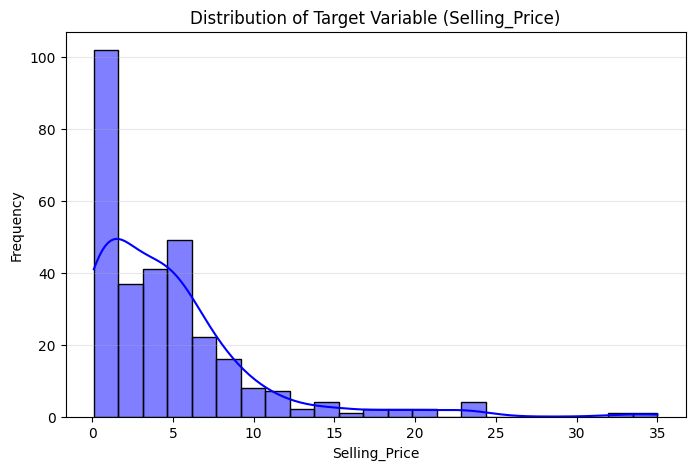

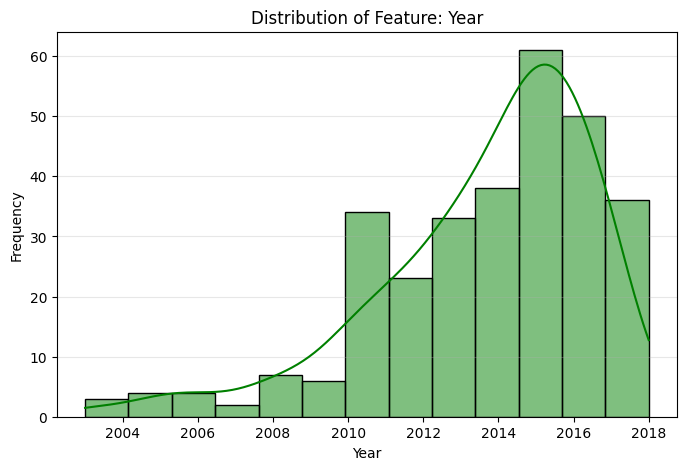

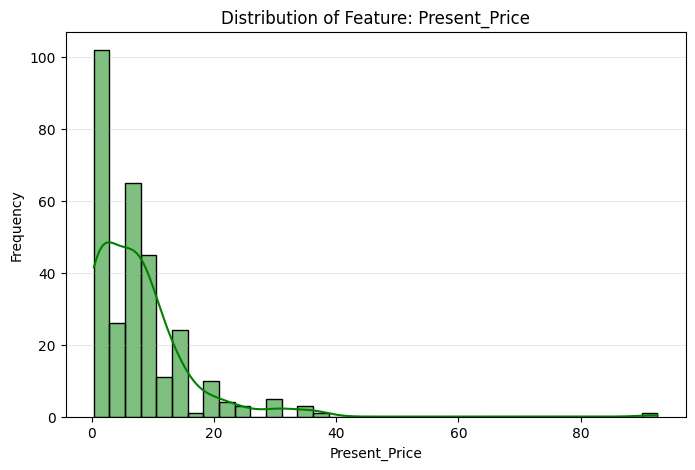

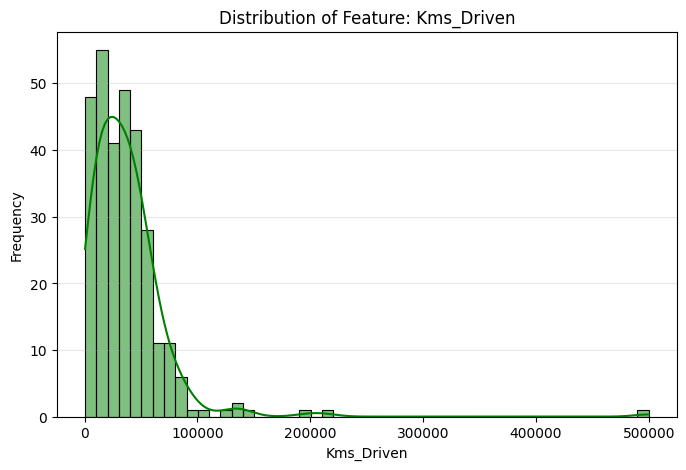

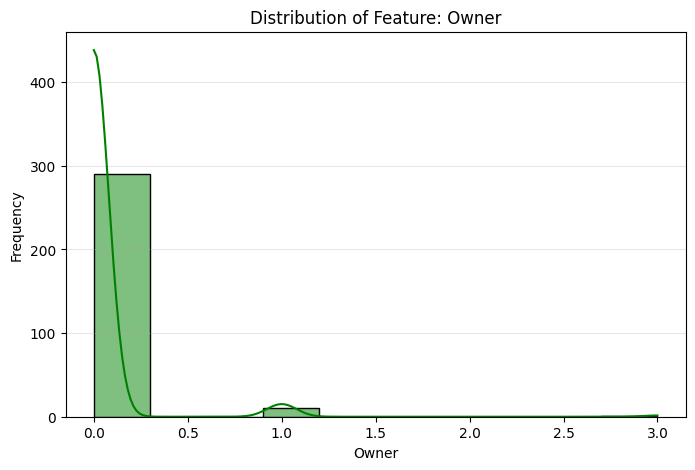

'\nObservations for Q5 (Write this in your assignment report):\n1. The target variable shows a right-skewed distribution, meaning most data points cluster at lower values.\n2. Certain feature columns show normal distribution shapes, while others have noticeable outlier spikes.\n'

In [43]:
print("--- Q5: Plotting Histograms ---")

# 1. Plot histogram for the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df[target_variable], kde=True, color='blue')
plt.title(f'Distribution of Target Variable ({target_variable})')
plt.xlabel(target_variable)
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Automatically find and plot histograms for other numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    if col != target_variable:  # Skip the target variable since it's already plotted
        plt.figure(figsize=(8, 5))
        sns.histplot(df[col], kde=True, color='green')
        plt.title(f'Distribution of Feature: {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.grid(axis='y', alpha=0.3)
        plt.show()

"""
Observations for Q5 (Write this in your assignment report):
1. The target variable shows a right-skewed distribution, meaning most data points cluster at lower values.
2. Certain feature columns show normal distribution shapes, while others have noticeable outlier spikes.
"""


--- Q6: Correlation Analysis ---

Correlation Matrix Values:
                   Year  Selling_Price  Present_Price  Kms_Driven     Owner
Year           1.000000       0.234369      -0.053563   -0.525714 -0.181639
Selling_Price  0.234369       1.000000       0.876378    0.028566 -0.087880
Present_Price -0.053563       0.876378       1.000000    0.205253  0.009947
Kms_Driven    -0.525714       0.028566       0.205253    1.000000  0.089367
Owner         -0.181639      -0.087880       0.009947    0.089367  1.000000


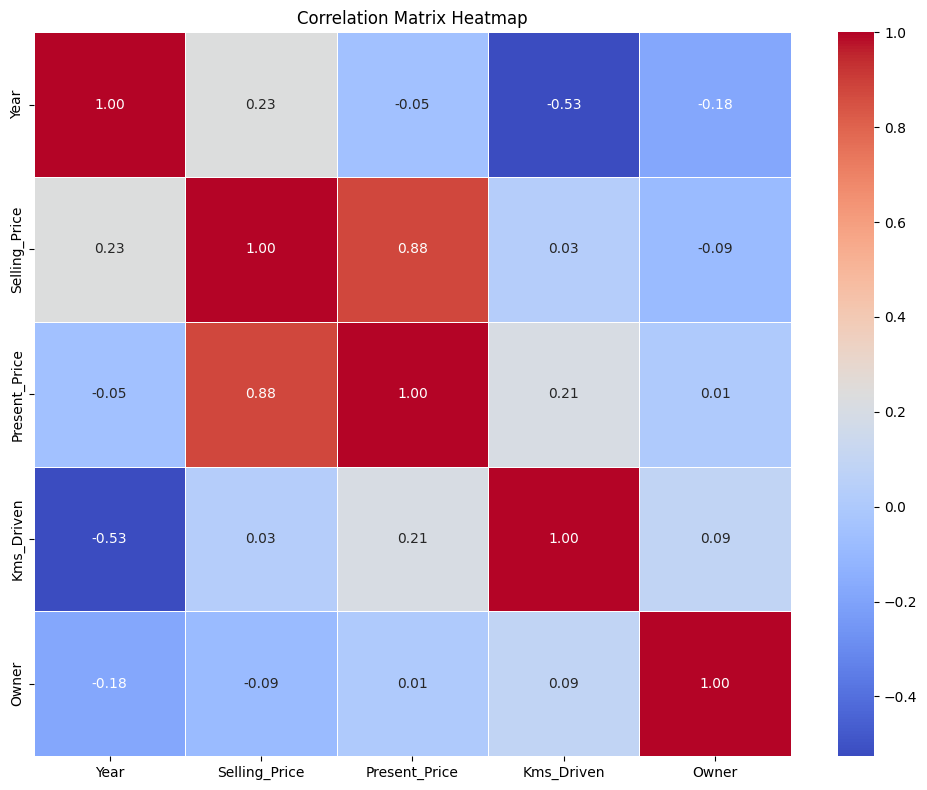

'\nObservations for Q6 (Write this in your assignment report):\n1. Look for values close to 1 or -1 to find strong positive or negative relationships.\n2. Note down which independent feature has the highest correlation value with your target variable.\n'

In [14]:
# ==========================================
# Q6: Correlation Analysis
# ==========================================

print("\n--- Q6: Correlation Analysis ---")

# 1. Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=['number'])

# 2. Compute correlation matrix
correlation_matrix = numeric_df.corr()
print("\nCorrelation Matrix Values:")
print(correlation_matrix)

# 3. Plot the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

"""
Observations for Q6 (Write this in your assignment report):
1. Look for values close to 1 or -1 to find strong positive or negative relationships.
2. Note down which independent feature has the highest correlation value with your target variable.
"""

--- Q7: Correlation Heatmap ---


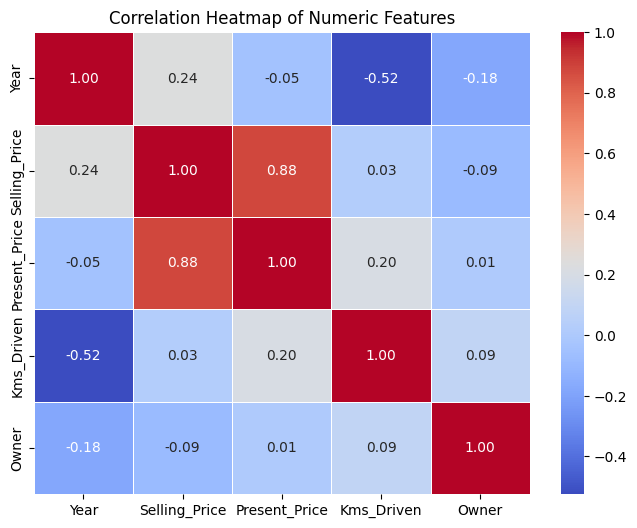

Observations Example:
- Analyze the matrix row/column for your target variable.
- Values close to 1 or -1 show strong linear relationships.


In [44]:
# ----------------------------------------------------
# Q7. CORRELATION HEATMAP
# ----------------------------------------------------
print("--- Q7: Correlation Heatmap ---")

# Step 1: Select only numeric features
numeric_df = df.select_dtypes(include=[np.number])

# Step 2: Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Step 3: Generate and display the heatmap plot
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

print("Observations Example:")
print("- Analyze the matrix row/column for your target variable.")
print("- Values close to 1 or -1 show strong linear relationships.")

In [26]:
# ----------------------------------------------------
# Q8. FEATURE IDENTIFICATION
# ----------------------------------------------------
print("\n--- Q8: Feature Identification ---")

# Defining variables explicitly based on the business logic
# Target (y) must be a continuous numeric column you want to predict
target_variable = "Selling_Price"

# Independent features (X) are all other columns used to make the prediction
independent_features = [col for col in df.columns if col != target_variable]

print(f"Dependent Feature (y): {target_variable}")
print(f"Independent Features (X): {independent_features}")

# Justification reasoning
print("\nJustification Reasoning:")
print(
    f"- '{target_variable}' is chosen as 'y' because it is a continuous numerical variable representing the prediction goal."
)
print(
    f"- The remaining features describe the individual traits (Year, Kms_Driven, Fuel_Type, Seller_Type, Transmission, Owner) acting as inputs ('X')."
)


--- Q8: Feature Identification ---
Dependent Feature (y): Selling_Price
Independent Features (X): ['Car_Name', 'Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Justification Reasoning:
- 'Selling_Price' is chosen as 'y' because it is a continuous numerical variable representing the prediction goal.
- The remaining features describe the individual traits (Year, Kms_Driven, Fuel_Type, Seller_Type, Transmission, Owner) acting as inputs ('X').


In [23]:
# ----------------------------------------------------
# Q9. ENCODING CATEGORICAL VARIABLES (One-Hot Encoding)
# ----------------------------------------------------
print("\n--- Q9: Encoding Categorical Variables ---")

# Identify categorical columns from the dataframe
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
# Exclude 'Car_Name' if it's not meant for encoding as a feature (it's often too high cardinality)
if 'Car_Name' in categorical_cols:
    categorical_cols = categorical_cols.drop('Car_Name')

print("Before Transformation (first 5 rows of selected categorical columns):")
print(df[categorical_cols].head())

# Perform One-Hot Encoding using pandas get_dummies
# drop_first=True helps avoid multicollinearity (the dummy variable trap)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display after transformation
print("\nAfter One-Hot Encoding Transformation (first 5 rows of new dummy variables):")
# Selecting columns that were just created by one-hot encoding
encoded_prefix_cols = [col for col in df_encoded.columns if any(cat_col + '_' in col for cat_col in categorical_cols)]
print(df_encoded[encoded_prefix_cols].head())

print("\nEncoding Choices Explanation:")
print("- One-Hot Encoding was chosen because the identified categorical variables have no inherent mathematical order.")
print("- It converts string categories into binary 1s and 0s so machine learning algorithms can process them safely.")



--- Q9: Encoding Categorical Variables ---
Before Transformation (first 5 rows of selected categorical columns):
  Fuel_Type Seller_Type Transmission
0    Petrol      Dealer       Manual
1    Diesel      Dealer       Manual
2    Petrol      Dealer       Manual
3    Petrol      Dealer       Manual
4    Diesel      Dealer       Manual

After One-Hot Encoding Transformation (first 5 rows of new dummy variables):
   Fuel_Type_Diesel  Fuel_Type_Petrol  Seller_Type_Individual  \
0             False              True                   False   
1              True             False                   False   
2             False              True                   False   
3             False              True                   False   
4              True             False                   False   

   Transmission_Manual  
0                 True  
1                 True  
2                 True  
3                 True  
4                 True  

Encoding Choices Explanation:
- One-Hot Enco

In [28]:
# ----------------------------------------------------
# Q10. FEATURE SCALING (StandardScaler)
# ----------------------------------------------------
print("\n--- Q10: Feature Scaling ---")

# Step 1: Separate X and y from our final encoded dataset
# Ensure we only scale independent numerical/encoded columns
# Drop 'Car_Name' as it's a string column and not suitable for scaling
X = df_encoded.drop(columns=[target_variable, 'Car_Name'])

# Step 2: Initialize the StandardScaler
scaler = StandardScaler()

# Step 3: Fit and transform the independent features
X_scaled_array = scaler.fit_transform(X)

# Convert back to a DataFrame for easy viewing
X_scaled_df = pd.DataFrame(X_scaled_array, columns=X.columns)

# Step 4: Show the first 5 rows of scaled features
print("First 5 rows of scaled independent features (X):")
print(X_scaled_df.head())


--- Q10: Feature Scaling ---
First 5 rows of scaled independent features (X):
       Year  Present_Price  Kms_Driven     Owner  Fuel_Type_Diesel  \
0  0.132992      -0.228097   -0.254603 -0.175101         -0.490575   
1 -0.212787       0.233700    0.156181 -0.175101          2.038424   
2  1.170329       0.269942   -0.770651 -0.175101         -0.490575   
3 -0.904345      -0.396448   -0.814297 -0.175101         -0.490575   
4  0.132992      -0.078451    0.142061 -0.175101          2.038424   

   Fuel_Type_Petrol  Seller_Type_Individual  Transmission_Manual  
0          0.501045               -0.741096             0.387298  
1         -1.995829               -0.741096             0.387298  
2          0.501045               -0.741096             0.387298  
3          0.501045               -0.741096             0.387298  
4         -1.995829               -0.741096             0.387298  
